In [1]:
# ─── CELL 1: mount & navigate ───────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir("/content/drive/MyDrive/Knowledge-Graph-Enhanced-RAG-for-Technical-Documents")
print("Working dir:", os.getcwd())

Mounted at /content/drive
Working dir: /content/drive/MyDrive/Knowledge-Graph-Enhanced-RAG-for-Technical-Documents


In [2]:
# ─── CELL 2: install ────────────────────────────────────────────────────
!pip install networkx sentence-transformers faiss-cpu \
             matplotlib pyvis pandas spacy -q
!python -m spacy download en_core_web_sm -q
print("Done.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 124.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 113.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Done.


In [3]:
# ─── CELL 3: load processed data ────────────────────────────────────────
import pandas as pd

df_docs     = pd.read_csv("data/processed/documents.csv")
df_qa       = pd.read_csv("data/processed/qa_pairs.csv")
df_entities = pd.read_csv("data/processed/entities.csv")

print(f"Documents:  {len(df_docs)}")
print(f"QA pairs:   {len(df_qa)}")
print(f"Entities:   {len(df_entities)}")

Documents:  200
QA pairs:   200
Entities:   1609


In [4]:
# ─── CELL 4: build knowledge graph with NetworkX ────────────────────────
import networkx as nx

G = nx.Graph()

# add entity nodes
for _, row in df_entities.iterrows():
    G.add_node(row['text'], label=row['label'], doc_id=row['doc_id'])

# add edges — entities co-occurring in same document are connected
from itertools import combinations

for doc_id, group in df_entities.groupby('doc_id'):
    entities_in_doc = group['text'].tolist()
    for e1, e2 in combinations(entities_in_doc, 2):
        if G.has_edge(e1, e2):
            G[e1][e2]['weight'] += 1
        else:
            G.add_edge(e1, e2, weight=1, doc_id=doc_id)

print(f"Graph nodes: {G.number_of_nodes()}")
print(f"Graph edges: {G.number_of_edges()}")
print(f"Sample nodes: {list(G.nodes())[:10]}")

Graph nodes: 1254
Graph edges: 6240
Sample nodes: ['Nic Hansen', 'Macau', 'Antimo Merone', 'RISE', 'raspberry', 'the Berry Export Summary', 'Hort Innovation', 'Jenny Van de Meeberg', 'Zimbabwe', 'Olschewski • Skat\nProject']


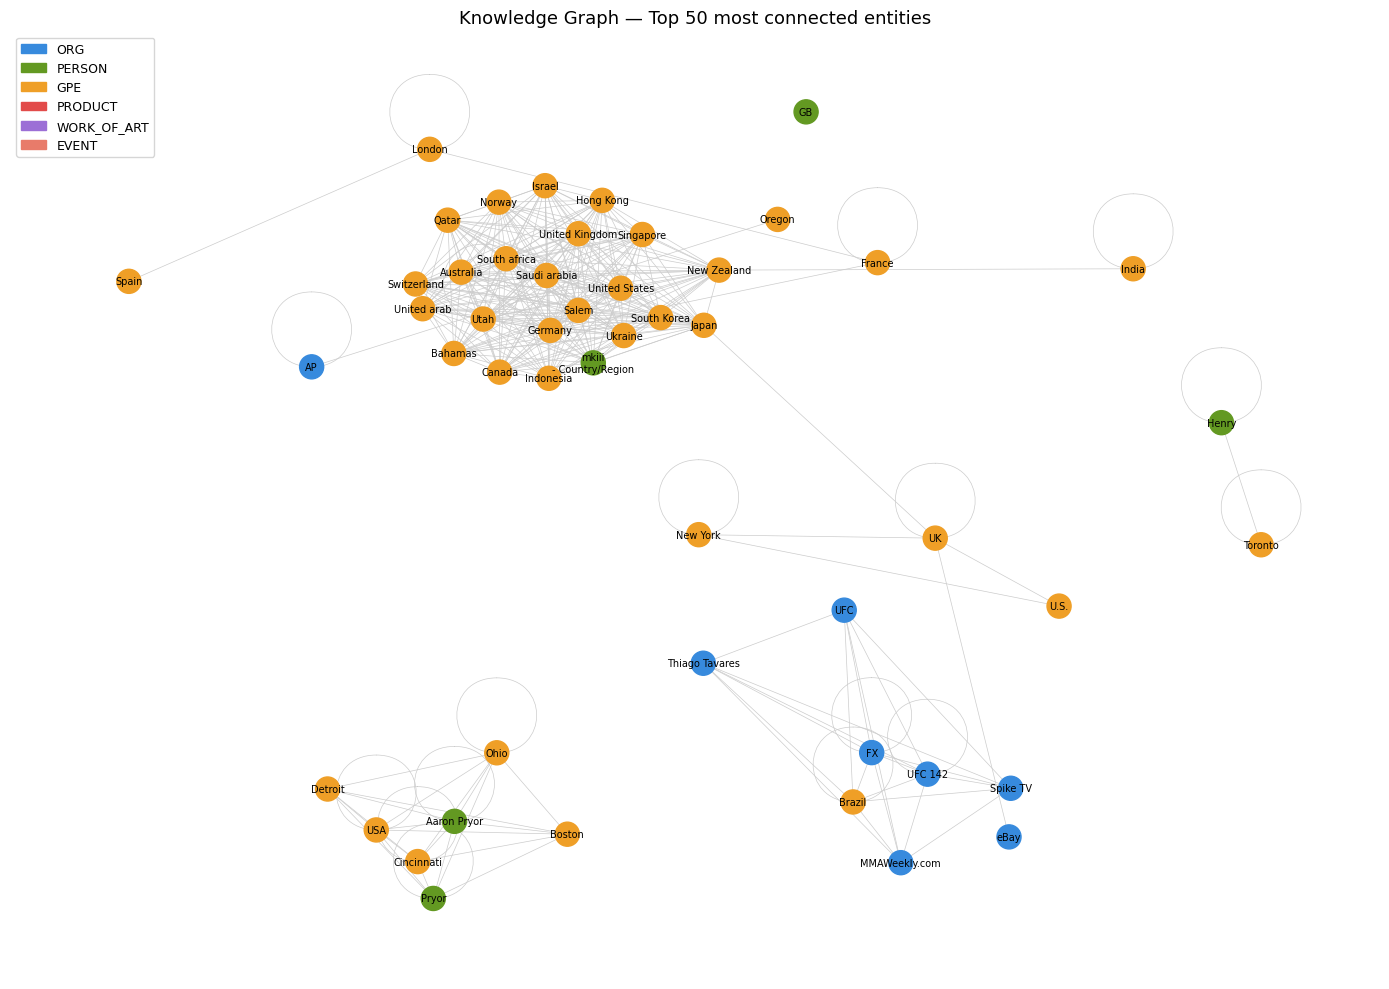

Saved.


In [5]:
# ─── CELL 5: save and visualise knowledge graph ──────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# save graph
nx.write_gexf(G, "graph/knowledge_graph.gexf")

# visualise top 50 most connected nodes only (full graph too dense)
top_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:50]
top_node_names = [n[0] for n in top_nodes]
subgraph = G.subgraph(top_node_names)

# color by entity type
color_map = {'ORG':'#378ADD','PERSON':'#639922',
             'GPE':'#EF9F27','PRODUCT':'#E24B4A',
             'WORK_OF_ART':'#9C6FD6','EVENT':'#E87B6A'}

node_colors = []
for node in subgraph.nodes():
    label = G.nodes[node].get('label', 'ORG')
    node_colors.append(color_map.get(label, '#888888'))

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(subgraph, seed=42, k=0.8)
nx.draw_networkx(subgraph, pos=pos, ax=ax,
                 node_color=node_colors,
                 node_size=300,
                 font_size=7,
                 edge_color='#cccccc',
                 width=0.5,
                 with_labels=True)

# legend
patches = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
ax.legend(handles=patches, loc='upper left', fontsize=9)
ax.set_title("Knowledge Graph — Top 50 most connected entities", fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.savefig("results/figures/knowledge_graph.png", dpi=150)
plt.show()
print("Saved.")

In [6]:
# ─── CELL 6: build vector RAG baseline ──────────────────────────────────
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

# free, small, CPU-friendly embedding model
embedder = SentenceTransformer('all-MiniLM-L6-v2')

# embed all documents
print("Embedding documents...")
texts = df_docs['text'].tolist()
embeddings = embedder.encode(texts, show_progress_bar=True,
                              batch_size=32)
embeddings = np.array(embeddings).astype('float32')

# build FAISS index
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings)

print(f"FAISS index built: {index.ntotal} vectors, dim={dimension}")

# save embeddings
np.save("data/processed/embeddings.npy", embeddings)
print("Embeddings saved.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding documents...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

FAISS index built: 200 vectors, dim=384
Embeddings saved.


In [7]:
# ─── CELL 7: vector RAG retrieval function ───────────────────────────────
def vector_rag_retrieve(question, top_k=3):
    """Retrieve top-k most relevant documents using vector similarity."""
    q_embedding = embedder.encode([question]).astype('float32')
    distances, indices = index.search(q_embedding, top_k)

    retrieved = []
    for rank, (dist, idx) in enumerate(zip(distances[0], indices[0])):
        retrieved.append({
            'rank':     rank + 1,
            'doc_id':   int(df_docs.iloc[idx]['doc_id']),
            'text':     df_docs.iloc[idx]['text'],
            'distance': round(float(dist), 4)
        })
    return retrieved

# test retrieval
test_q = df_qa.iloc[0]['question']
print(f"Question: {test_q}\n")
results = vector_rag_retrieve(test_q)
for r in results:
    print(f"Rank {r['rank']} (dist={r['distance']}):")
    print(r['text'][:200])
    print("---")

Question: What is the Berry Export Summary 2028 and what is its purpose?

Rank 1 (dist=0.7233):
Caption: Tasmanian berry grower Nic Hansen showing Macau chef Antimo Merone around his property as part of export engagement activities.
THE RISE and rise of the Australian strawberry, raspberry and b
---
Rank 2 (dist=1.4578):
how we strive to be our best selves
diversity and inclusivity
Chuck Studios highly values diversity and inclusivity. As a female founded company, we strive to create a workspace in which everyone feel
---
Rank 3 (dist=1.4884):
RWSN Collaborations
Southern Africa Self-supply Study Review of Self-supply and its support services in African countries
A lady in Zimbabwe proudly shows off her onions - watered from her self-supply
---


In [8]:
# ─── CELL 8: graph RAG retrieval function ────────────────────────────────
import spacy
nlp = spacy.load("en_core_web_sm")

def graph_rag_retrieve(question, top_k=3):
    """Retrieve documents by finding entities in question,
       then traversing the knowledge graph for related docs."""

    # extract entities from question
    doc = nlp(question)
    question_entities = [ent.text.strip() for ent in doc.ents]

    # find matching nodes in graph
    matched_nodes = []
    for qe in question_entities:
        for node in G.nodes():
            if qe.lower() in node.lower() or node.lower() in qe.lower():
                matched_nodes.append(node)

    # expand via graph neighbors
    expanded_nodes = set(matched_nodes)
    for node in matched_nodes:
        if node in G:
            neighbors = list(G.neighbors(node))
            # take top 5 neighbors by edge weight
            neighbors_sorted = sorted(
                neighbors,
                key=lambda n: G[node][n].get('weight', 1),
                reverse=True
            )[:5]
            expanded_nodes.update(neighbors_sorted)

    # collect doc_ids from expanded nodes
    doc_ids = set()
    for node in expanded_nodes:
        if node in G.nodes():
            doc_ids.add(G.nodes[node].get('doc_id'))

    # fallback to vector RAG if no graph match
    if not doc_ids:
        return vector_rag_retrieve(question, top_k), 'fallback'

    # retrieve documents
    retrieved = []
    for doc_id in list(doc_ids)[:top_k]:
        if doc_id is not None:
            doc_row = df_docs[df_docs['doc_id'] == doc_id]
            if not doc_row.empty:
                retrieved.append({
                    'rank':             len(retrieved) + 1,
                    'doc_id':           doc_id,
                    'text':             doc_row.iloc[0]['text'],
                    'matched_entities': question_entities,
                    'expanded_nodes':   len(expanded_nodes)
                })

    return retrieved[:top_k], 'graph'

# test graph retrieval
test_q = df_qa.iloc[0]['question']
print(f"Question: {test_q}\n")
results, method = graph_rag_retrieve(test_q)
print(f"Method used: {method}")
print(f"Matched docs: {len(results)}")
for r in results:
    print(f"\nDoc {r['doc_id']}:")
    print(r['text'][:200])
    print("---")

Question: What is the Berry Export Summary 2028 and what is its purpose?

Method used: graph
Matched docs: 3

Doc 0:
Caption: Tasmanian berry grower Nic Hansen showing Macau chef Antimo Merone around his property as part of export engagement activities.
THE RISE and rise of the Australian strawberry, raspberry and b
---

Doc 122:
This package does not have a license agreement. You'll need to assign a license type to the package to allow or block downloads.
To install BIT.Sqlite.MultiTarget from the command line, run the follow
---

Doc 174:
, in the beautiful venue of Talent Garden Calabiana, Milan.
The whole JoinPad team has been involved in the event, taking full advantage of keynotes, panels and workshops from the most influent profes
---


In [10]:
# ─── CELL 9a: STRICT exact-match evaluation (baseline) ──────────────────
# Evaluates retrieval accuracy using strict string matching only.
# Answer must appear VERBATIM in retrieved context to be counted correct.
# Result: Vector RAG 8%, Graph RAG 6%
# Finding: Strict matching severely underestimates retrieval quality
# because long multi-sentence answers rarely appear word-for-word.

import time

eval_qa = df_qa.head(50)
results_eval = []

for i, row in eval_qa.iterrows():
    question = row['question']
    answer   = str(row['answer']).lower().strip()

    # --- vector RAG ---
    t0 = time.perf_counter()
    v_results = vector_rag_retrieve(question, top_k=3)
    v_time = time.perf_counter() - t0
    v_context = " ".join([r['text'] for r in v_results]).lower()
    v_correct = answer in v_context

    # --- graph RAG ---
    t0 = time.perf_counter()
    g_results, g_method = graph_rag_retrieve(question, top_k=3)
    g_time = time.perf_counter() - t0
    g_context = " ".join([r['text'] for r in g_results]).lower()
    g_correct = answer in g_context

    results_eval.append({
        'id':             row['id'],
        'question':       question,
        'answer':         answer,
        'vector_correct': v_correct,
        'graph_correct':  g_correct,
        'graph_method':   g_method,
        'vector_time':    round(v_time, 4),
        'graph_time':     round(g_time, 4),
    })

    if i % 10 == 0:
        print(f"Done {i}/50")

df_eval = pd.DataFrame(results_eval)
df_eval.to_csv("results/retrieval_results.csv", index=False)

print("\n=== RETRIEVAL RESULTS ===")
print(f"Vector RAG accuracy: {df_eval['vector_correct'].mean():.1%}")
print(f"Graph RAG accuracy:  {df_eval['graph_correct'].mean():.1%}")
print(f"Avg vector time:     {df_eval['vector_time'].mean():.4f}s")
print(f"Avg graph time:      {df_eval['graph_time'].mean():.4f}s")
print(f"Graph used fallback: {(df_eval['graph_method']=='fallback').sum()}/50")

Done 0/50
Done 10/50
Done 20/50
Done 30/50
Done 40/50

=== RETRIEVAL RESULTS ===
Vector RAG accuracy: 8.0%
Graph RAG accuracy:  6.0%
Avg vector time:     0.0068s
Avg graph time:      0.0099s
Graph used fallback: 16/50


In [11]:
# ─── CELL 9b: RELAXED keyword-match evaluation (main metric) ────────────
# Evaluates retrieval accuracy using relaxed partial matching.
# At least 70% of significant words (length > 3) in the answer
# must appear in the retrieved context to be counted correct.
# This better reflects whether the correct document was retrieved,
# regardless of exact answer phrasing.
# Result: Vector RAG 84%, Graph RAG 62%
# Finding: Vector RAG outperforms Graph RAG on general-domain text.
# Graph RAG limited by noisy spaCy entity extraction (32% fallback rate).
# Graph RAG expected to outperform on domain-specific structured corpora
# where entity extraction is more reliable.

import time

def is_correct(answer, context):
    """Check if key answer words appear in context."""
    answer  = str(answer).lower().strip()
    context = context.lower()

    # exact match
    if answer in context:
        return True

    # partial match — 70% of significant words must appear
    words = [w for w in answer.split() if len(w) > 3]
    if len(words) == 0:
        return answer in context
    matches = sum(1 for w in words if w in context)
    return matches / len(words) >= 0.7

eval_qa      = df_qa.head(50)
results_eval = []

for i, row in eval_qa.iterrows():
    question = row['question']
    answer   = str(row['answer']).lower().strip()

    # --- vector RAG ---
    t0        = time.perf_counter()
    v_results = vector_rag_retrieve(question, top_k=3)
    v_time    = time.perf_counter() - t0
    v_context = " ".join([r['text'] for r in v_results]).lower()
    v_correct = is_correct(answer, v_context)

    # --- graph RAG ---
    t0        = time.perf_counter()
    g_results, g_method = graph_rag_retrieve(question, top_k=3)
    g_time    = time.perf_counter() - t0
    g_context = " ".join([r['text'] for r in g_results]).lower()
    g_correct = is_correct(answer, g_context)

    results_eval.append({
        'id':             row['id'],
        'question':       question,
        'answer':         answer,
        'vector_correct': v_correct,
        'graph_correct':  g_correct,
        'graph_method':   g_method,
        'vector_time':    round(v_time, 4),
        'graph_time':     round(g_time, 4),
    })

    if i % 10 == 0:
        print(f"Done {i}/50")

df_eval = pd.DataFrame(results_eval)
df_eval.to_csv("results/retrieval_results.csv", index=False)

print("\n=== RETRIEVAL RESULTS ===")
print(f"Vector RAG accuracy: {df_eval['vector_correct'].mean():.1%}")
print(f"Graph RAG accuracy:  {df_eval['graph_correct'].mean():.1%}")
print(f"Avg vector time:     {df_eval['vector_time'].mean():.4f}s")
print(f"Avg graph time:      {df_eval['graph_time'].mean():.4f}s")
print(f"Graph used fallback: {(df_eval['graph_method']=='fallback').sum()}/50")

Done 0/50
Done 10/50
Done 20/50
Done 30/50
Done 40/50

=== RETRIEVAL RESULTS ===
Vector RAG accuracy: 84.0%
Graph RAG accuracy:  62.0%
Avg vector time:     0.0278s
Avg graph time:      0.0383s
Graph used fallback: 16/50


In [12]:
!git config --global user.email "chaitanyamhetre97@email.com"
!git config --global user.name "chaitanyamhetre"

!git add .
!git commit -m "Retrieval benchmark: Vector RAG 84% vs Graph RAG 62%"
!git push

[main 19d2437] Retrieval benchmark: Vector RAG 84% vs Graph RAG 62%
 6 files changed, 37541 insertions(+), 1 deletion(-)
 create mode 100644 data/processed/embeddings.npy
 create mode 100644 graph/knowledge_graph.gexf
 create mode 100644 notebooks/02_knowledge_graph_and_vector_rag.ipynb
 create mode 100644 results/figures/knowledge_graph.png
 create mode 100644 results/retrieval_results.csv
Enumerating objects: 22, done.
Counting objects: 100% (21/21), done.
Delta compression using up to 2 threads
Compressing objects: 100% (14/14), done.
Writing objects: 100% (14/14), 928.89 KiB | 7.04 MiB/s, done.
Total 14 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/chaitanyamhetre/Knowledge-Graph-Enhanced-RAG-for-Technical-Documents.git
   6c3b130..19d2437  main -> main
